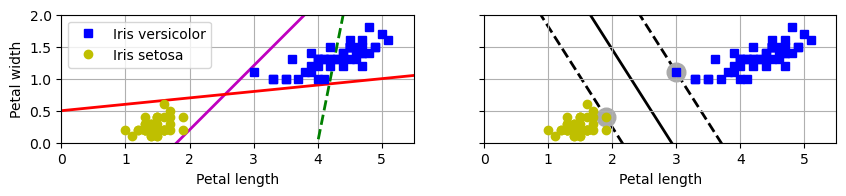

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVC
from sklearn import datasets

iris = datasets.load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target

setosa_or_versicolor = (y == 0) | (y == 1)
X = X[setosa_or_versicolor]
y = y[setosa_or_versicolor]

# SVM 분류 모델
svm_clf = SVC(kernel="linear", C=10**9)
svm_clf.fit(X, y)

# 나쁜 모델
x0 = np.linspace(0, 5.5, 200)
pred_1 = 5 * x0 - 20
pred_2 = x0 - 1.8
pred_3 = 0.1 * x0 + 0.5

def plot_svc_decision_boundary(svm_clf, xmin, xmax):
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]

    # 결정 경계에서, w0*x0 + w1*x1 + b = 0
    # => x1 = -w0/w1 * x0 - b/w1
    x0 = np.linspace(xmin, xmax, 200)
    decision_boundary = -w[0] / w[1] * x0 - b / w[1]

    margin = 1/w[1]
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin
    svs = svm_clf.support_vectors_

    plt.plot(x0, decision_boundary, "k-", linewidth=2, zorder=-2)
    plt.plot(x0, gutter_up, "k--", linewidth=2, zorder=-2)
    plt.plot(x0, gutter_down, "k--", linewidth=2, zorder=-2)
    plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#AAA',
                zorder=-1)

fig, axes = plt.subplots(ncols=2, figsize=(10, 2.7), sharey=True)

plt.sca(axes[0])
plt.plot(x0, pred_1, "g--", linewidth=2)
plt.plot(x0, pred_2, "m-", linewidth=2)
plt.plot(x0, pred_3, "r-", linewidth=2)
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris versicolor")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris setosa")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper left")
plt.axis([0, 5.5, 0, 2])
plt.gca().set_aspect("equal")
plt.grid()

plt.sca(axes[1])
plot_svc_decision_boundary(svm_clf, 0, 5.5)
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo")
plt.xlabel("Petal length")
plt.axis([0, 5.5, 0, 2])
plt.gca().set_aspect("equal")
plt.grid()
plt.show()

In [2]:
# 결정트리
# 지니계수 / 엔트로피
# 지니계수 (불순도) / 엔트로피 (불확실성)
# 앙상블 : 배깅 / 부스팅 / 스태킹
# 차원 축소 : 차원의 저주 (pca) -> 차원이 증가할수록 데이터가 희소해지는 현상 / 분산이 커지는 방향으로 새로운 축을 만들어 축소

In [4]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

train = pd.read_csv('datasets/data/train.csv')
test = pd.read_csv('datasets/data/test.csv')

print(f"학습 데이터 크기: {train.shape}")
print(f"테스트 데이터 크기: {test.shape}")

TARGET = 'avg_delay_minutes_next_30m'
ID_COLS = ['ID', 'layout_id', 'scenario_id']

feature_cols = [c for c in train.columns if c not in ID_COLS + [TARGET]]
print(f"피처 수: {len(feature_cols)}")

학습 데이터 크기: (250000, 94)
테스트 데이터 크기: (50000, 93)
피처 수: 90


In [5]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(train))
test_preds = np.zeros(len(test))

for fold, (tr_idx, val_idx) in enumerate(kf.split(train)):
    print(f"── Fold {fold + 1} ──")
    X_tr = train.loc[tr_idx, feature_cols]
    y_tr = train.loc[tr_idx, TARGET]
    X_val = train.loc[val_idx, feature_cols]
    y_val = train.loc[val_idx, TARGET]

    model = LGBMRegressor(
        n_estimators=1000, learning_rate=0.05, max_depth=7,
        num_leaves=63, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=0.1, random_state=42, verbose=-1,
    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
    )

    oof_preds[val_idx] = model.predict(X_val)
    test_preds += model.predict(test[feature_cols]) / 5

── Fold 1 ──
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 494.261
[200]	valid_0's l2: 474.567
[300]	valid_0's l2: 460.88
[400]	valid_0's l2: 450.216
[500]	valid_0's l2: 442.736
[600]	valid_0's l2: 436.378
[700]	valid_0's l2: 430.24
[800]	valid_0's l2: 425.243
[900]	valid_0's l2: 421.239
[1000]	valid_0's l2: 417.524
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l2: 417.524
── Fold 2 ──
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 503.98
[200]	valid_0's l2: 485.04
[300]	valid_0's l2: 473.31
[400]	valid_0's l2: 464.703
[500]	valid_0's l2: 458.153
[600]	valid_0's l2: 451.458
[700]	valid_0's l2: 445.839
[800]	valid_0's l2: 440.982
[900]	valid_0's l2: 436.954
[1000]	valid_0's l2: 433.272
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l2: 433.272
── Fold 3 ──
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 468.227
[200]	valid_0's l2: 448.275
[300]	valid

In [6]:
oof_mae = mean_absolute_error(train[TARGET], oof_preds)
print(f"OOF MAE: {oof_mae:.4f}")

OOF MAE: 9.2405


In [14]:
from sklearn.ensemble import RandomForestRegressor

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(train))
test_preds = np.zeros(len(test))

for fold, (tr_idx, val_idx) in enumerate(kf.split(train)):
    print(f"── Fold {fold + 1} ──")
    X_tr = train.loc[tr_idx, feature_cols]
    y_tr = train.loc[tr_idx, TARGET]
    X_val = train.loc[val_idx, feature_cols]
    y_val = train.loc[val_idx, TARGET]

    model = RandomForestRegressor(
        n_estimators=1000, max_depth=7, random_state=42
    )
    model.fit(X_tr, y_tr)

    oof_preds[val_idx] = model.predict(X_val)
    test_preds += model.predict(test[feature_cols]) / 5

── Fold 1 ──


KeyboardInterrupt: 